In [53]:
import numpy as np
import matplotlib.pyplot as plt

states = range(1, 100)

In [54]:
thresholds = [1e-4, 1e-6, 1e-8, 1e-10]

p_win = 0.4

data = []
for theta in thresholds:
    V = np.zeros(101)
    V[0] = 0.0
    V[100] = 1.0
    policy = np.zeros((len(states), ))

    while True:
        delta = 0.0

        for s in states:
            old_value = V[s]

            # valid actions
            actions = np.arange(1, min(s, 100 - s) + 1)
          
            # action-values
            q = np.asarray([p_win * V[s + a] + (1 - p_win) * V[s - a] for a in actions])
            max_q = q.max()
            
            # update state-value
            V[s] = max_q
            delta = max(delta, abs(V[s] - old_value))

        if delta < theta:            
            break

    for s in states:
        actions = np.arange(1, min(s, 100 - s) + 1)
        q = np.asarray([p_win * V[s + a] + (1 - p_win) * V[s - a] for a in actions])
        max_q = q.max()

        tied = np.isclose(q, max_q, atol=1e-10, rtol=0)

        policy[s - 1] = actions[tied].min()
    
    data.append((V, policy))


In [55]:
def plot_V(data):
    all_v = []
    policies = []
    n = len(thresholds)

    for i in range(len(data)):
        all_v.append(data[i][0])
        policies.append(data[i][1])

    fig, ax = plt.subplots(n, 2, figsize = (14, 9))

    for i in range(n):
        ax[i, 0].plot(np.arange(101), all_v[i])
        ax[i, 0].set_title(f"threshold: {thresholds[i]}")
        ax[i, 0].set_xlabel("state")
        ax[i, 0].set_ylabel("V(s)")

        ax[i, 1].plot(np.arange(1, 100), policies[i])
        ax[i, 1].set_title(f"threshold: {thresholds[i]}")
        ax[i, 1].set_xlabel("state")
        ax[i, 1].set_ylabel("policy(s)")

    fig.tight_layout()
    fig.show()

/var/folders/nc/zryj2zls3zq9hn7llw1scq7w0000gn/T/ipykernel_61650/3782844163.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


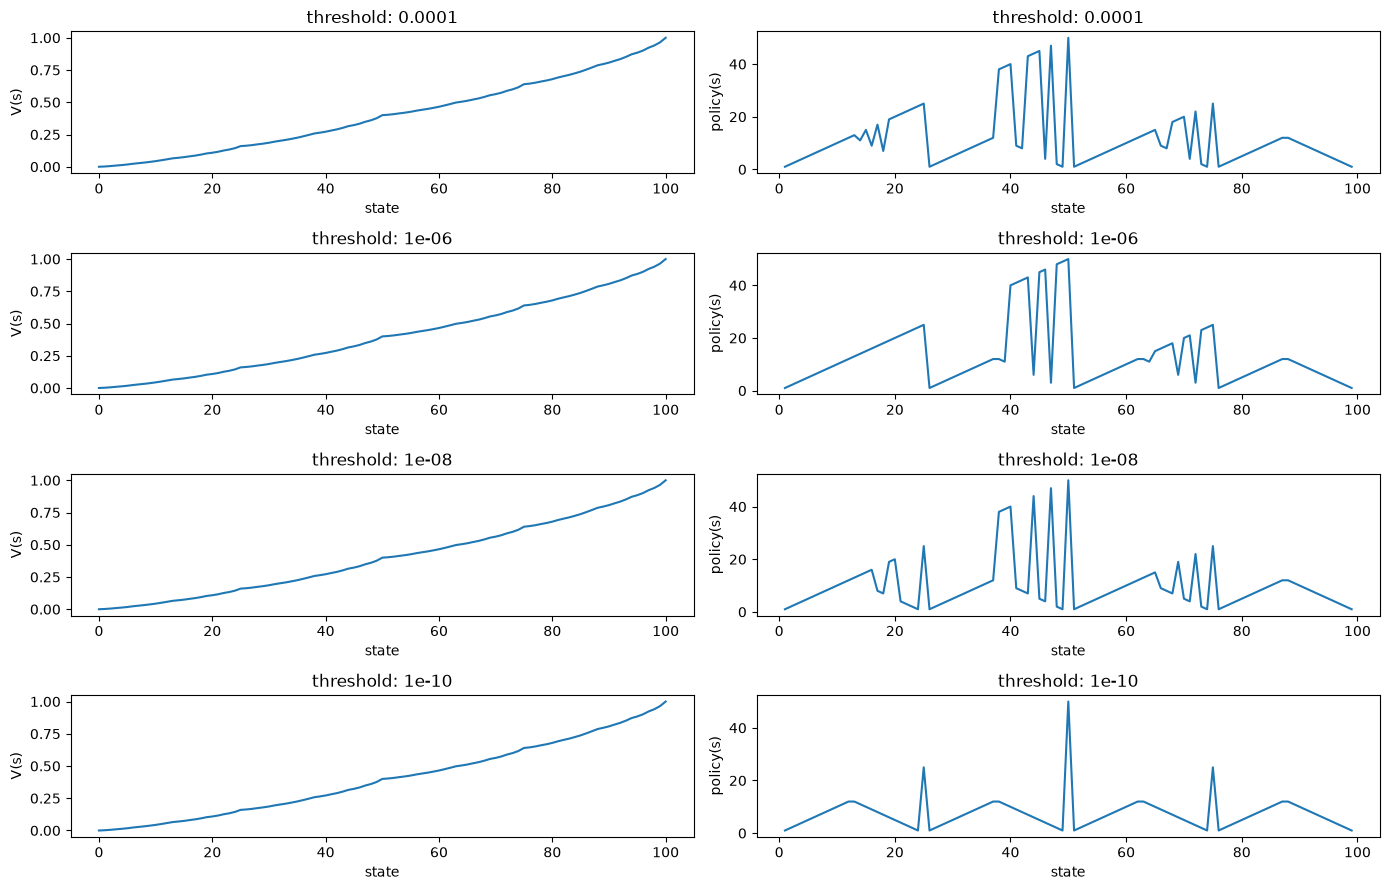

In [56]:
plot_V(data)

As we decreashe `theta`, the policy get closer and closer to the optimal policy, ending with the optimal in `theta` = 1e-10. This is because with higher `theta` the algorithm converges faster with a non-optimal policy.

## p_win = 0.55

In [57]:
thresholds = [1e-4, 1e-6, 1e-8, 1e-10]

p_win = 0.55

data = []
for theta in thresholds:
    V = np.zeros(101)
    V[0] = 0.0
    V[100] = 1.0
    policy = np.zeros((len(states), ))

    while True:
        delta = 0.0

        for s in states:
            old_value = V[s]

            # valid actions
            actions = np.arange(1, min(s, 100 - s) + 1)
          
            # action-values
            q = np.asarray([p_win * V[s + a] + (1 - p_win) * V[s - a] for a in actions])
            max_q = q.max()
            
            # update state-value
            V[s] = max_q
            delta = max(delta, abs(V[s] - old_value))

        if delta < theta:            
            break

    for s in states:
        actions = np.arange(1, min(s, 100 - s) + 1)
        q = np.asarray([p_win * V[s + a] + (1 - p_win) * V[s - a] for a in actions])
        max_q = q.max()

        tied = np.isclose(q, max_q, atol=1e-10, rtol=0)

        policy[s - 1] = actions[tied].min()
    
    data.append((V, policy))


/var/folders/nc/zryj2zls3zq9hn7llw1scq7w0000gn/T/ipykernel_61650/3782844163.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


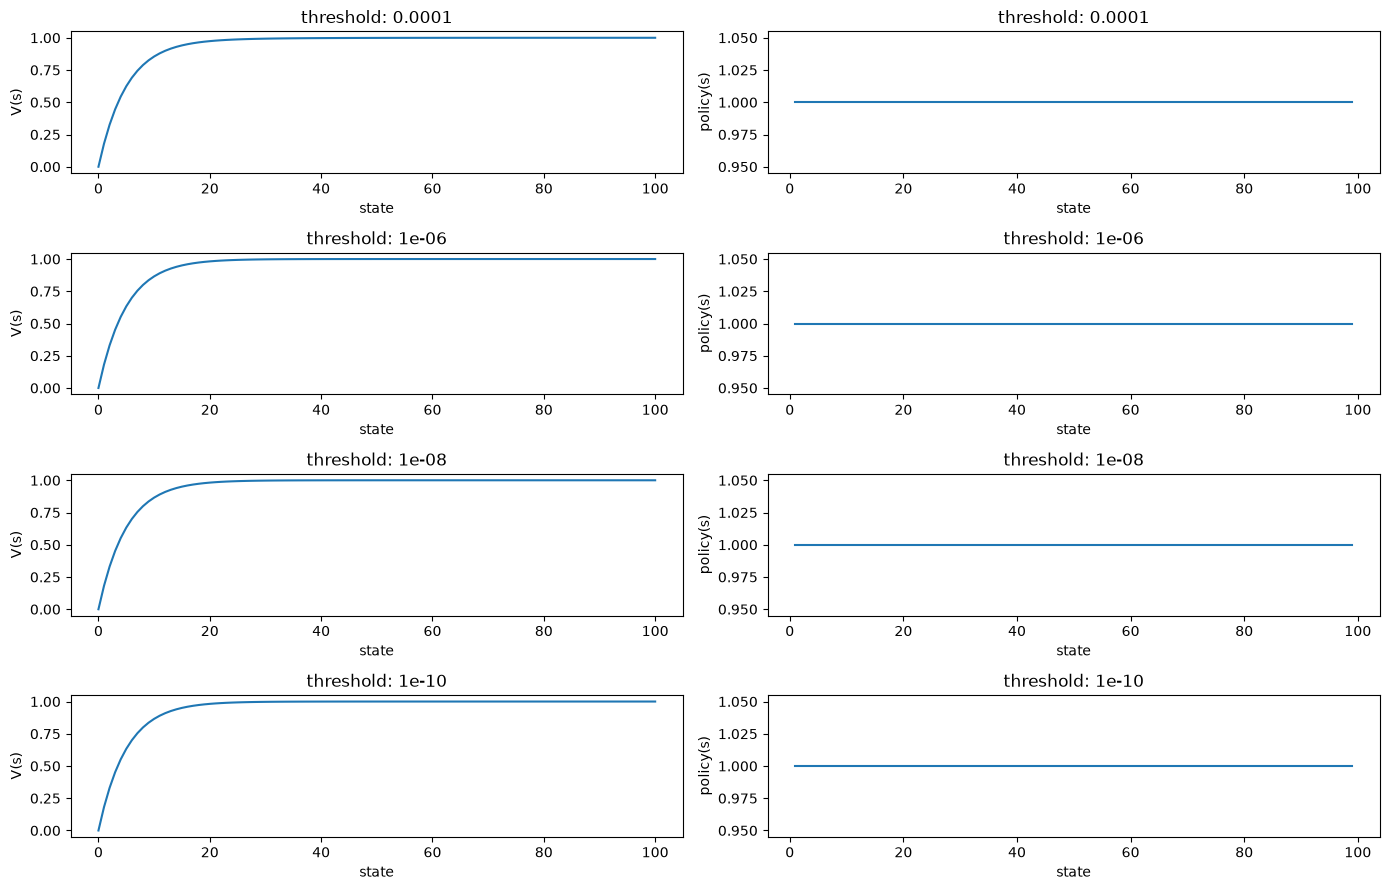

In [58]:
plot_V(data)

# p_win = 0.25

In [59]:
thresholds = [1e-4, 1e-6, 1e-8, 1e-10]

p_win = 0.25

data = []
for theta in thresholds:
    V = np.zeros(101)
    V[0] = 0.0
    V[100] = 1.0
    policy = np.zeros((len(states), ))

    while True:
        delta = 0.0

        for s in states:
            old_value = V[s]

            # valid actions
            actions = np.arange(1, min(s, 100 - s) + 1)
          
            # action-values
            q = np.asarray([p_win * V[s + a] + (1 - p_win) * V[s - a] for a in actions])
            max_q = q.max()
            
            # update state-value
            V[s] = max_q
            delta = max(delta, abs(V[s] - old_value))

        if delta < theta:            
            break

    for s in states:
        actions = np.arange(1, min(s, 100 - s) + 1)
        q = np.asarray([p_win * V[s + a] + (1 - p_win) * V[s - a] for a in actions])
        max_q = q.max()

        tied = np.isclose(q, max_q, atol=1e-10, rtol=0)

        policy[s - 1] = actions[tied].min()
    
    data.append((V, policy))


/var/folders/nc/zryj2zls3zq9hn7llw1scq7w0000gn/T/ipykernel_61650/3782844163.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


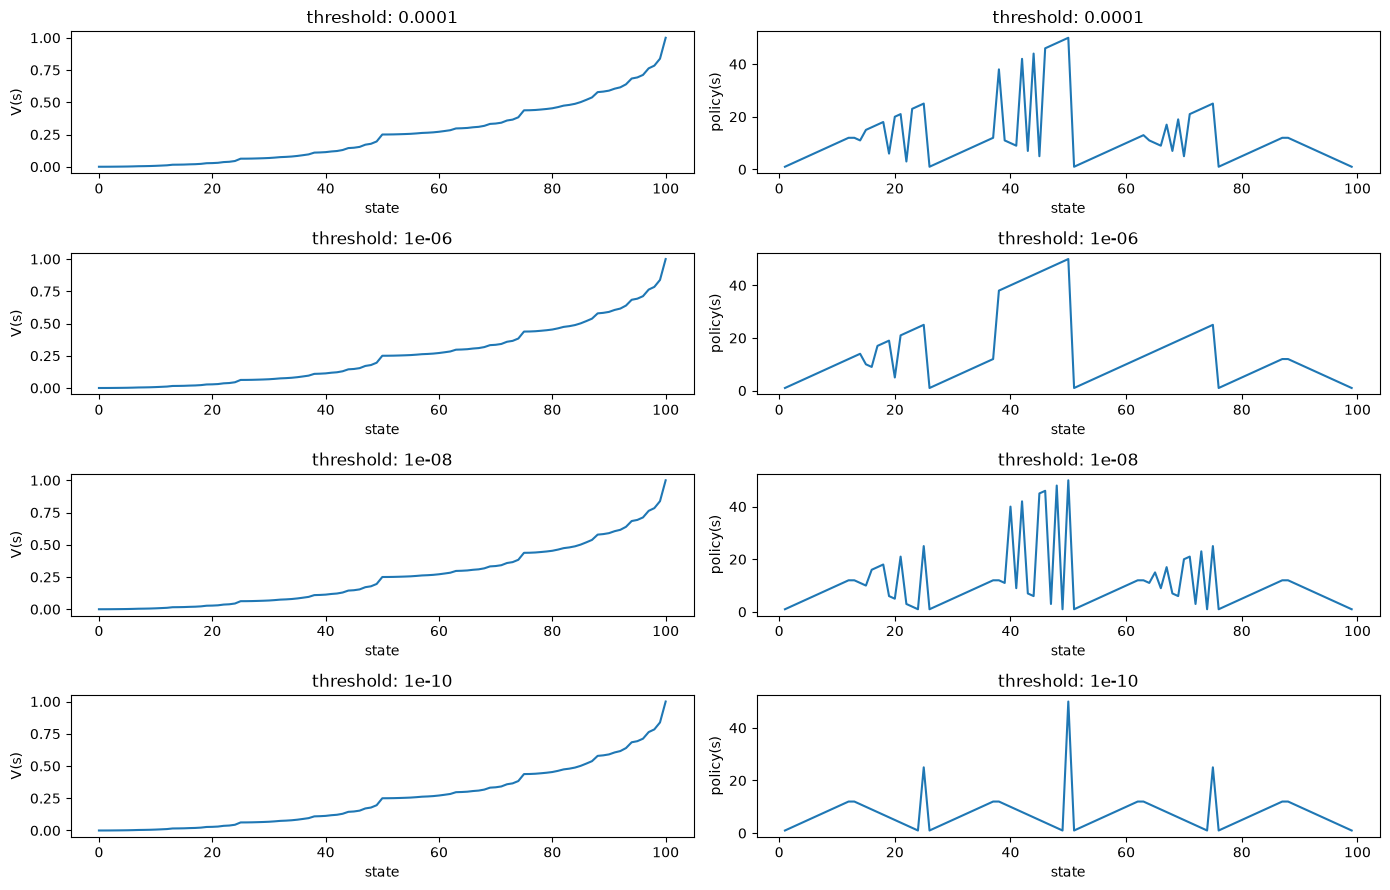

In [60]:
plot_V(data)

if favourable coin --> we want to do as many step as possible (positive EV when we throw the coin) --> policy ~ 1
if not favourable --> already discussed, balance in middle states except for 25, 50, 75